# Chapter 18. Where to Go Next

Companion notebook for *Python from Zero*. Most of this chapter is about
habits and tools you use outside Python (Git, virtual environments,
getting help). The cells below are the small tastes of other libraries.
The pandas cells need `pandas` installed (`py -m pip install pandas` or
`python3 -m pip install pandas`); if it is not, you will see a
`ModuleNotFoundError`, which is fine: read the chapter's output instead.

## 18.5 Data analysis: a taste of pandas

In [1]:
import pandas as pd

animals = pd.read_csv("../data/animals.csv")
print(animals.shape)
print(animals["species"].value_counts())

(48, 12)
species
Dog           20
Cat           16
Rabbit         7
Guinea pig     5
Name: count, dtype: int64


In [2]:
print(animals.groupby("species")["age_years"].mean().round(1))

species
Cat           6.9
Dog           5.2
Guinea pig    2.8
Rabbit        2.3
Name: age_years, dtype: float64


In [3]:
donations = pd.read_csv("../data/donations.csv")
print(donations.groupby("method")["amount"].sum())

method
card      2400
cash      2550
online    2855
Name: amount, dtype: int64


## Charts with matplotlib

[1855, 1050, 1135, 1425, 1410, 930]


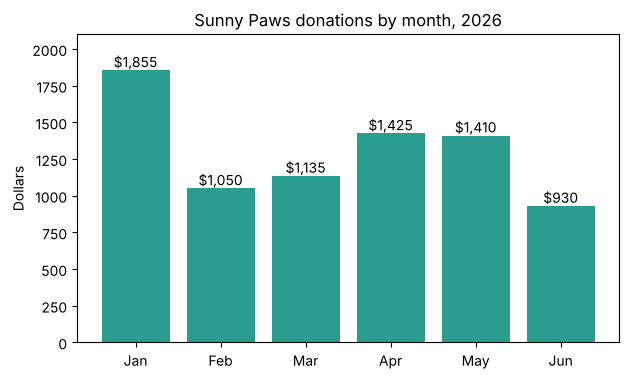

In [4]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
totals = [0, 0, 0, 0, 0, 0]
with open("../data/donations.csv", encoding="utf-8", newline="") as file:
    for row in csv.DictReader(file):
        month = int(row["date"][5:7])
        totals[month - 1] += int(row["amount"])
print(totals)

plt.figure(figsize=(7, 4))
bars = plt.bar(MONTHS, totals, color="#2A9D8F")
plt.bar_label(bars, labels=[f"${total:,}" for total in totals])
plt.title("Sunny Paws donations by month, 2026")
plt.ylabel("Dollars")
plt.ylim(0, 2100)
Path("output").mkdir(exist_ok=True)
plt.savefig("output/ch18_donations_by_month.png", dpi=200)
plt.show()

## Web apps with Flask (not run here: it starts a web server)

```python
# sunny_paws_web.py  (needs: pip install flask)
from flask import Flask

app = Flask(__name__)


@app.route("/")
def home():
    return "<h1>Welcome to Sunny Paws Animal Rescue</h1>"


if __name__ == "__main__":
    app.run(debug=True)
```

## 18.10 Exercises

1. Draw a bar chart of how many animals of each species the shelter
   has, and save it to `output/`.
2. Draw a bar chart of the donations by payment method.
3. Use `help()` to read about `statistics.median()`, then find the
   median weight of the shelter's dogs.
4. Write a minimal example that reproduces
   `TypeError: can only concatenate str (not "int") to str`, as you
   would paste it into a question.
5. Put the Shelter Manager under Git, with a `.gitignore`.
6. Create a virtual environment and prove that you are using it.
7. Plan and start a small portfolio project of your own: write its
   requirements, one function and one test.